In [2]:
from scipy.stats import spearmanr
from scipy.stats import pearsonr
import numpy as np
import os
from sklearn.linear_model import LinearRegression
import copy
import pandas as pd
from funciones import indice_J
from scipy.interpolate import PchipInterpolator


In [3]:
#dataframe datos de compositores 
def extraer_dataset_musica():

    datos_composers = {}
    carpeta = r'data\Sequences\labels'
    archivos_en_carpeta = os.listdir(carpeta)
    index0 = 0
    indice = 0

    for archivo in archivos_en_carpeta:
        ruta_completa = os.path.join(carpeta, archivo)
        serie = pd.read_csv(ruta_completa, header = None)
        composer = archivo.split('-')[1].capitalize() # nombre compositor
        datos_composers[composer] = {} #genero bibio para composer
        datos_composers[composer]['Birth_year'] = archivo.split('-')[0] #año de nacimiento
        index1 = serie.iloc[0, 0].split('\t')[0] #el # del primer serie del composer
        index2 = int(serie.iloc[len(serie)-3, 0].split('\t')[0]) - index0 # # Piezas
        index0 = index2 + index0 # numero total de piezas anteriores
        datos_composers[composer]['# Piezas'] = index2 # Piezas
        datos_composers[composer]['Indice'] = indice
        indice += 1

    composers = {}
    M = 0
    carpeta = r'data\Sequences\Series'
    archivos_en_carpeta = os.listdir(carpeta)

    for archivo in archivos_en_carpeta:
        ruta_completa = os.path.join(carpeta, archivo)
        serie = pd.read_csv(ruta_completa)
        # escoge una serie
        composer = archivo.split('-')[1].capitalize() # nombre compositor
        composers[composer] = {}

        for pieza in range( datos_composers[composer]['# Piezas'] ):
            N = serie.iloc[0, 0].split('\t')[1] # # de elementos por pieza
            M = int(N) + M
            index_n1 = 0 
            index_n2 = int(N)+2 
            serie_n = serie[index_n1 + 2:index_n2].reset_index(drop=True) # resetear index
            serie = serie[index_n2 +1:] # recortar serie Original
            serie_n.index += 1 # que index empiece desde 1
            num_serie_T = serie.columns[0]  # numero de serie de todo el dataset
            num_serie = pieza + 1
            composers[composer]['Serie_'+str(num_serie)] = serie_n.squeeze().to_numpy().astype(float) # agregamos pieza al dicc composer con key como # serie

    ###
    ###

    composers_depurado = copy.deepcopy(composers)
    datos_composers_depurado = copy.deepcopy(datos_composers)

    for i,composer in enumerate(composers.keys()):
        d = 0
        for pieza in composers[composer].keys():
            if len(composers[composer][pieza])//2 < 400:
                del composers_depurado[composer][pieza]
                d = d + 1
        datos_composers_depurado[composer]['# Piezas'] = datos_composers[composer]['# Piezas'] - d


    # 40 promedio de numero de piezas por compositor
    composers_depurado_v2 = copy.deepcopy(composers_depurado)
    composers_depurado_v2_keychange = copy.deepcopy(composers_depurado_v2)
    datos_composers_depurado_v2 = copy.deepcopy(datos_composers_depurado)

    for composer in composers.keys():
        if datos_composers_depurado[composer]['# Piezas'] < 30:
            del composers_depurado_v2[composer]
            del datos_composers_depurado_v2[composer]
        
    for i,composer in enumerate(composers_depurado_v2.keys()):
        datos_composers_depurado_v2[composer]['Indice'] = i 

    for composer in composers_depurado_v2.keys():
        for i,serie in enumerate(composers_depurado_v2[composer].keys()):
            composers_depurado_v2_keychange[composer]['Serie_' + str(i+1)] = composers_depurado_v2_keychange[composer].pop(serie)

    print(" # de compositores restantes: ", len(composers_depurado_v2))

    return composers_depurado_v2, datos_composers_depurado_v2

composers, datos_composers = extraer_dataset_musica()

 # de compositores restantes:  19


# Calculos

In [4]:
# import numpy as np
# xi_index = np.array([])
# for composer in composers.keys():
#     xi_index = np.concatenate((xi_index,np.load('xi_index1/'+str(datos_composers[composer]['Birth_year'])+'_'+str(composer)+'_xi.npy')[:,1]))
# np.save('xi_index_global.npy',xi_index)

In [5]:
import numpy as np
from scipy.stats import pearsonr, spearmanr

def corr_puntos_rojos(X,Y,X_c,Y_c):
    X_bin = X >= X_c
    Y_bin = Y <= Y_c

    # Máscara de coincidencia: True si ambos están por encima o ambos por debajo del umbral
    mask_coincidencia = (X_bin & Y_bin) | (~X_bin & ~Y_bin)

    # Filtrar X e Y usando la máscara
    X_coinc = X[mask_coincidencia]
    Y_coinc = Y[mask_coincidencia]

    # Correlaciones solo en los puntos coincidentes
    pearson_coinc, _ = pearsonr(X_coinc, Y_coinc)
    spearman_coinc, _ = spearmanr(X_coinc, Y_coinc)

    return pearson_coinc, spearman_coinc


(2, 189991)


mean 0.05003915137046426


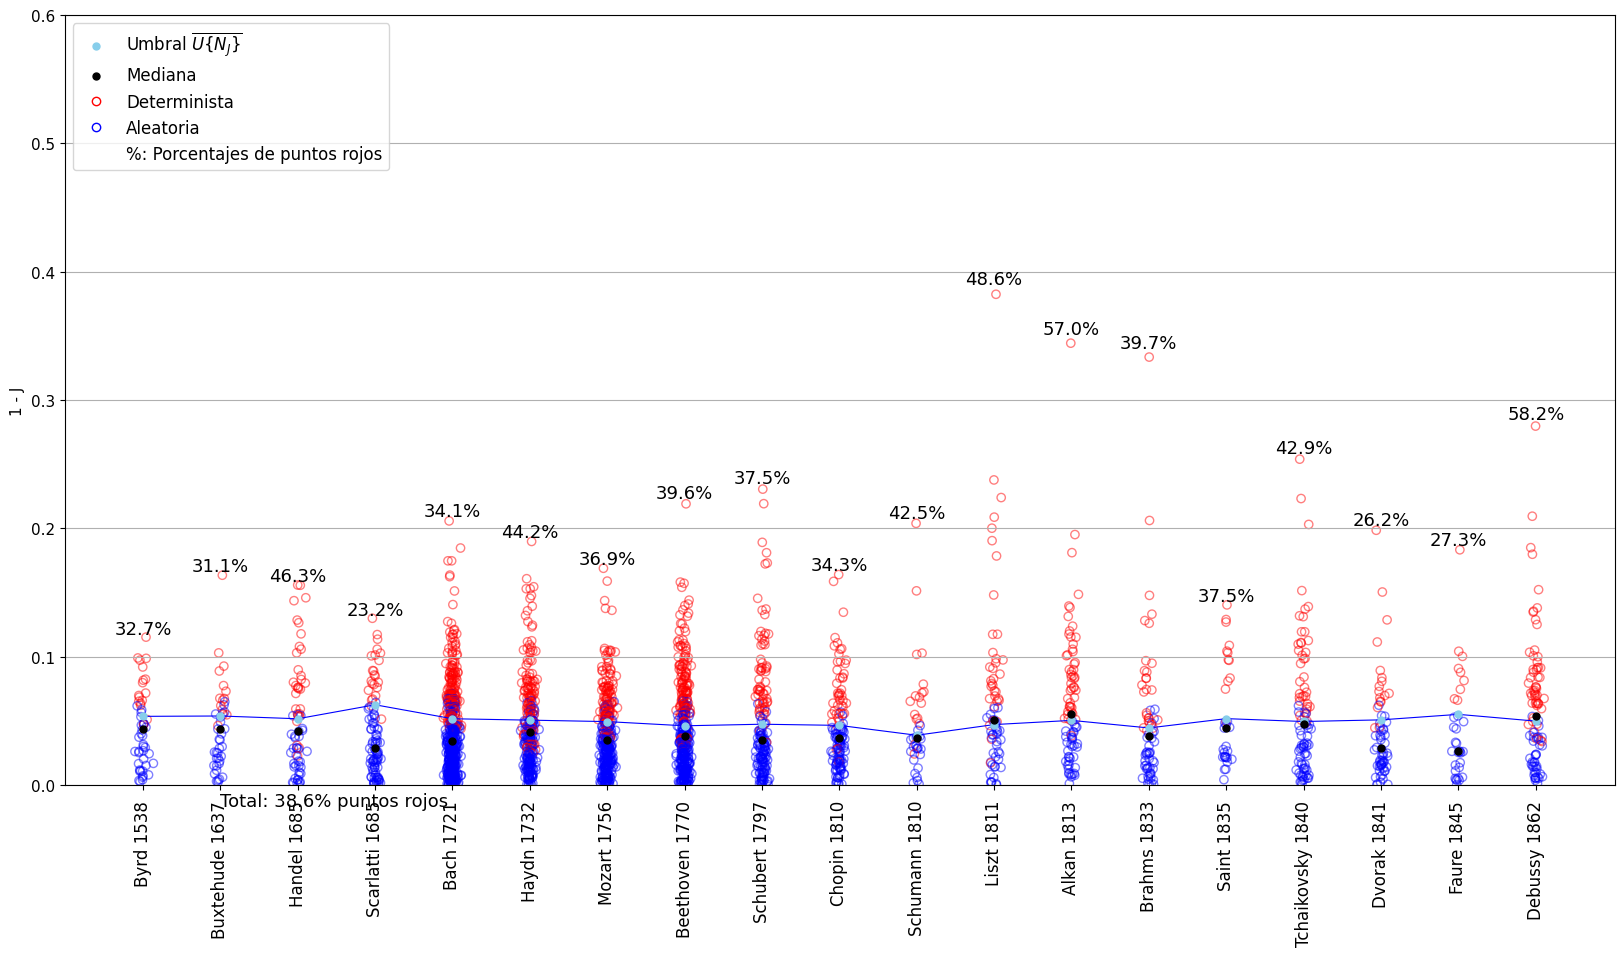

In [6]:
"""Scatter J"""

import numpy as np
import matplotlib.pyplot as plt
import os
import pickle
from matplotlib.lines import Line2D

num_compositores = 19
Ns = np.load('data/Ns_depurado.npy')
J_null_matrix = np.load(r'new_data\J_null_continuo.npy')
J_minus = J_null_matrix[:2,:]
# J_minus = np.load('data\J_minus_continuo.npy')
print(np.shape(J_minus))

pts_interp = 1
carpeta2 = 'data/J_lineal_sincorte_depurado/interp_'+str(pts_interp)
# carpeta2 = 'data/J_hermite_sincorte_depurado/interp_'+str(pts_interp) 
carpeta_new = 'new_data/Js'

archivos_en_carpeta2 = os.listdir(carpeta2)
archivos_en_carpeta_new = os.listdir(carpeta_new)

data2 = [1 - np.sort(np.load(os.path.join(carpeta2, array)))[:] for array in archivos_en_carpeta2]
Ns_data = [Ns[array] for array in range(np.shape(Ns)[0])]
J_new = [1-np.sort(np.load(os.path.join(carpeta_new, array)))[:] for array in archivos_en_carpeta_new]

data2 = [array[~np.isnan(array)] for array in J_new]
Ns_data = [array[~np.isnan(array)] for array in Ns_data]

for j in range(num_compositores):
    for i in range(len(Ns_data[j])):
        Ns_data[j][i] = (Ns_data[j][i] - 1)*pts_interp + Ns_data[j][i]
        # if Ns_data[j][i]//2 >= 13920:
        #     Ns_data[j][i] = 27840

umbral = [[1-J_minus[1, np.where(J_minus[0] == i//2)[0]][0] for i in Ns_data[j]] for j in range(num_compositores)]
# Aquí, asume que `puntos` es la lista con los num_compositores elementos
# puntos1 = [J_minus[int(np.mean(Ns_data[j])) - 20] for j in range(num_compositores)]
puntos2 = [1-np.mean(np.array([J_minus[1, np.where(J_minus[0] == i//2)[0]] for i in Ns_data[j]])) for j in range(num_compositores)]
mediana = [np.median(array) for array in data2]
print('mean',np.mean(puntos2))
fig, ax = plt.subplots(figsize=(20, 10))
# box2 = ax.boxplot(data2, patch_artist=True)

total_red_points = 0
total_points = 0
porcentajes = []
for i, (d, u) in enumerate(zip(data2, umbral)):
    # Añadir dispersión para evitar superposición
    x = np.random.normal(i + 1, 0.04, size=len(d))
    colors = ['blue' if d_val < u_val else 'red' for d_val, u_val in zip(d, [x for x in u])]
    plt.scatter(x, d, alpha=0.5, color='none', edgecolors=colors)
    # Calcular porcentaje de puntos rojos
    num_red = sum(c == 'red' for c in colors)
    total_points += len(d)
    total_red_points += num_red
    percentage_red = (num_red / len(d)) * 100
    porcentajes.append(percentage_red)
    # Calcular la posición del texto sin exceder el margen superior
    y_text = min(max(d) + 0.05, ax.get_ylim()[1] - 0.05)  # Limitar la posición de texto al margen superior
    
    # Añadir texto con el porcentaje
    ax.text(i + 1,np.max(d)*1.02, f'{percentage_red:.1f}%', ha='center', fontsize=13, color='black')

# np.save('porcentajes_run_avg_50.npy', np.array(porcentajes))
total_percentage_red = (total_red_points / total_points) * 100

# Añadir texto con el porcentaje total
ymin = ax.get_ylim()[0]   # límite inferior actual del eje y
xmin = ax.get_xlim()[0]   # si quieres fijarlo también en el mínimo de x, por ejemplo

# Añadir texto en coordenadas de datos
ax.text(xmin + 0.1*(ax.get_xlim()[1]-ax.get_xlim()[0]),  # un poquito a la derecha del xmin
        ymin,                                            # justo en ymin
        f'Total: {total_percentage_red:.1f}% puntos rojos',
        ha='left', va='bottom', fontsize=13, color='black')

ax.set_ylabel('1 - J', fontsize=11)
ax.tick_params(axis='y', labelsize=11)
ax.set_xticks(np.arange(1, num_compositores+1))

# ax.scatter(np.arange(1, 78), puntos1, color='red', s=50, zorder=3, marker = '*', label=r'$U\{\overline{N_J}\}$')
ax.scatter(np.arange(1, num_compositores+1), puntos2, color='#87CEEB', s=25, zorder=3, marker = 'o', label=r'Umbral $\overline{U\{ N_J \}}$')
# ax.axhline(y=0.029071461469613136)
ax.scatter(np.arange(1, num_compositores+1), mediana, color='black',s=25,zorder=3,marker='o',label='Mediana')
ax.plot(np.arange(1, num_compositores+1), puntos2, color='blue', linestyle='-', linewidth=0.8)
# ax.plot(np.arange(1, 18), mediana, color='red', linestyle='-', linewidth=0.8)
ax.plot([],[], marker = 'o',color='none', markeredgecolor='red', label = 'Determinista')
ax.plot([],[], marker='o', color='none', markeredgecolor='blue', label= 'Aleatoria')
ax.plot([],[], marker='none', color='none', label = '%: Porcentajes de puntos rojos')

# Agregar la leyenda al gráfico
ax.legend(loc='upper left',fontsize=12)
ax.set_ylim(0,0.6)
ax.set_xticklabels([f"{composer} {datos_composers[composer]['Birth_year']} " for i, composer in enumerate(datos_composers.keys())], rotation=90,fontsize=12)
plt.grid(axis='y')
plt.show()

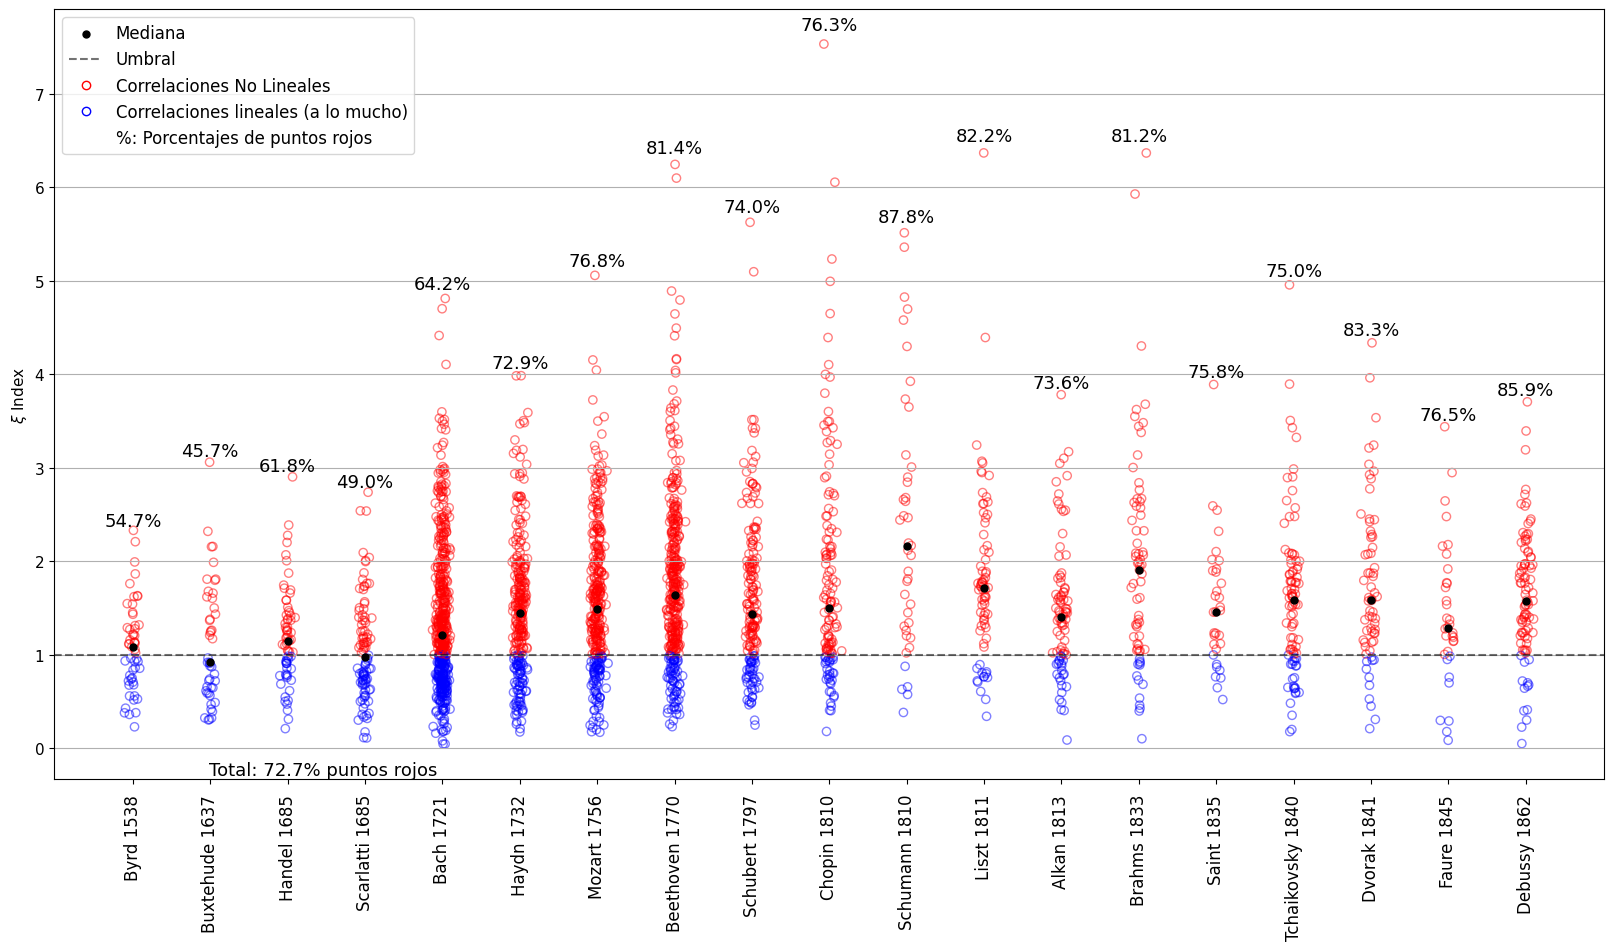

In [7]:
"""Scatter xi"""

import numpy as np
import matplotlib.pyplot as plt
import os
from matplotlib.lines import Line2D

xi_index = []
# carpeta = r'new_data/xi_index_mdfa'
carpeta = r'data/xi_index1'
for archivo in os.listdir(carpeta):
    ruta_completa = os.path.join(carpeta, archivo)
    array = np.load(ruta_completa)[:,1] -0.2
    xi_index.append(array)


# Aquí, asume que `puntos` es la lista con los num_compositores elementos
median = [np.median(array) for array in xi_index]

fig, ax = plt.subplots(figsize=(20, 10))

total_red_points = 0
total_points = 0
porcentajes_xi = []
for i, d in enumerate(xi_index):
    u = [1.0]*len(d)
    # Añadir dispersión para evitar superposición
    x = np.random.normal(i + 1, 0.04, size=len(d))
    colors = ['blue' if d_val < u_val else 'red' for d_val, u_val in zip(d, [x for x in u])]
    plt.scatter(x, d, alpha=0.5, color='none', edgecolors=colors)
    # Calcular porcentaje de puntos rojos
    num_red = sum(c == 'red' for c in colors)
    total_points += len(d)
    total_red_points += num_red
    percentage_red = (num_red / len(d)) * 100
    porcentajes_xi.append(percentage_red)
    # Calcular la posición del texto sin exceder el margen superior
    # Añadir texto con el porcentaje
    ax.text(i + 1,np.max(d[~np.isnan(d)])*1.02, f'{percentage_red:.1f}%', ha='center', fontsize=13, color='black')

# np.save('porcentajes_run_avg_50.npy', np.array(porcentajes))
total_percentage_red = (total_red_points / total_points) * 100

# Añadir texto con el porcentaje total
ymin = ax.get_ylim()[0]   # límite inferior actual del eje y
xmin = ax.get_xlim()[0]   # si quieres fijarlo también en el mínimo de x, por ejemplo

# Añadir texto en coordenadas de datos
ax.text(xmin + 0.1*(ax.get_xlim()[1]-ax.get_xlim()[0]),  # un poquito a la derecha del xmin
        ymin,                                            # justo en ymin
        f'Total: {total_percentage_red:.1f}% puntos rojos',
        ha='left', va='bottom', fontsize=13, color='black')


# ax.set_xlabel(r'Distribución del índice de no linealidad $\xi$ de las melodias', fontsize=13)
ax.set_ylabel(r'$\xi$ Index', fontsize = 11)
ax.tick_params(axis='y', labelsize=11)
ax.set_xticks(np.arange(1, 19+1))

# ax.scatter(np.arange(1, 78), puntos1, color='red', s=50, zorder=3, marker = '*', label=r'$U\{\overline{N_J}\}$')
ax.scatter(np.arange(1, 19+1), median, color='black',s=25,zorder=3,marker='o',label='Mediana')
ax.axhline(y=1.0, color='black', linestyle='--', alpha =0.55, label = 'Umbral')
# ax.plot(np.arange(1, 18), mediana, color='red', linestyle='-', linewidth=0.8)
ax.plot([],[], marker = 'o',color='none', markeredgecolor='red', label = 'Correlaciones No Lineales')
ax.plot([],[], marker='o', color='none', markeredgecolor='blue', label= 'Correlaciones lineales (a lo mucho)')
ax.plot([],[], marker='none', color='none', label = '%: Porcentajes de puntos rojos')

# Agregar la leyenda al gráfico
# ax.legend(handles=legend_elements)
ax.legend(loc='upper left', fontsize = 12)
# ax.xaxis.set_label_position('top')  # Movemos la etiqueta del eje x
# ax.xaxis.tick_top()  # Movemos los ticks del eje x a la parte superior
# ax.spines['top'].set_position(('axes', 1.0))  # Movemos la espina superior al tope de la figura
# ax.spines['bottom'].set_position(('axes', -0.1))  # Ocultamos la espina inferior
ax.set_xticklabels([f"{composer} {datos_composers[composer]['Birth_year']} " for i, composer in enumerate(list(datos_composers.keys()))], rotation=90, fontsize = 12)


plt.grid(axis='y')
plt.show()

In [8]:
len(np.concatenate(data2))

2658

mean 0.9613213391526967


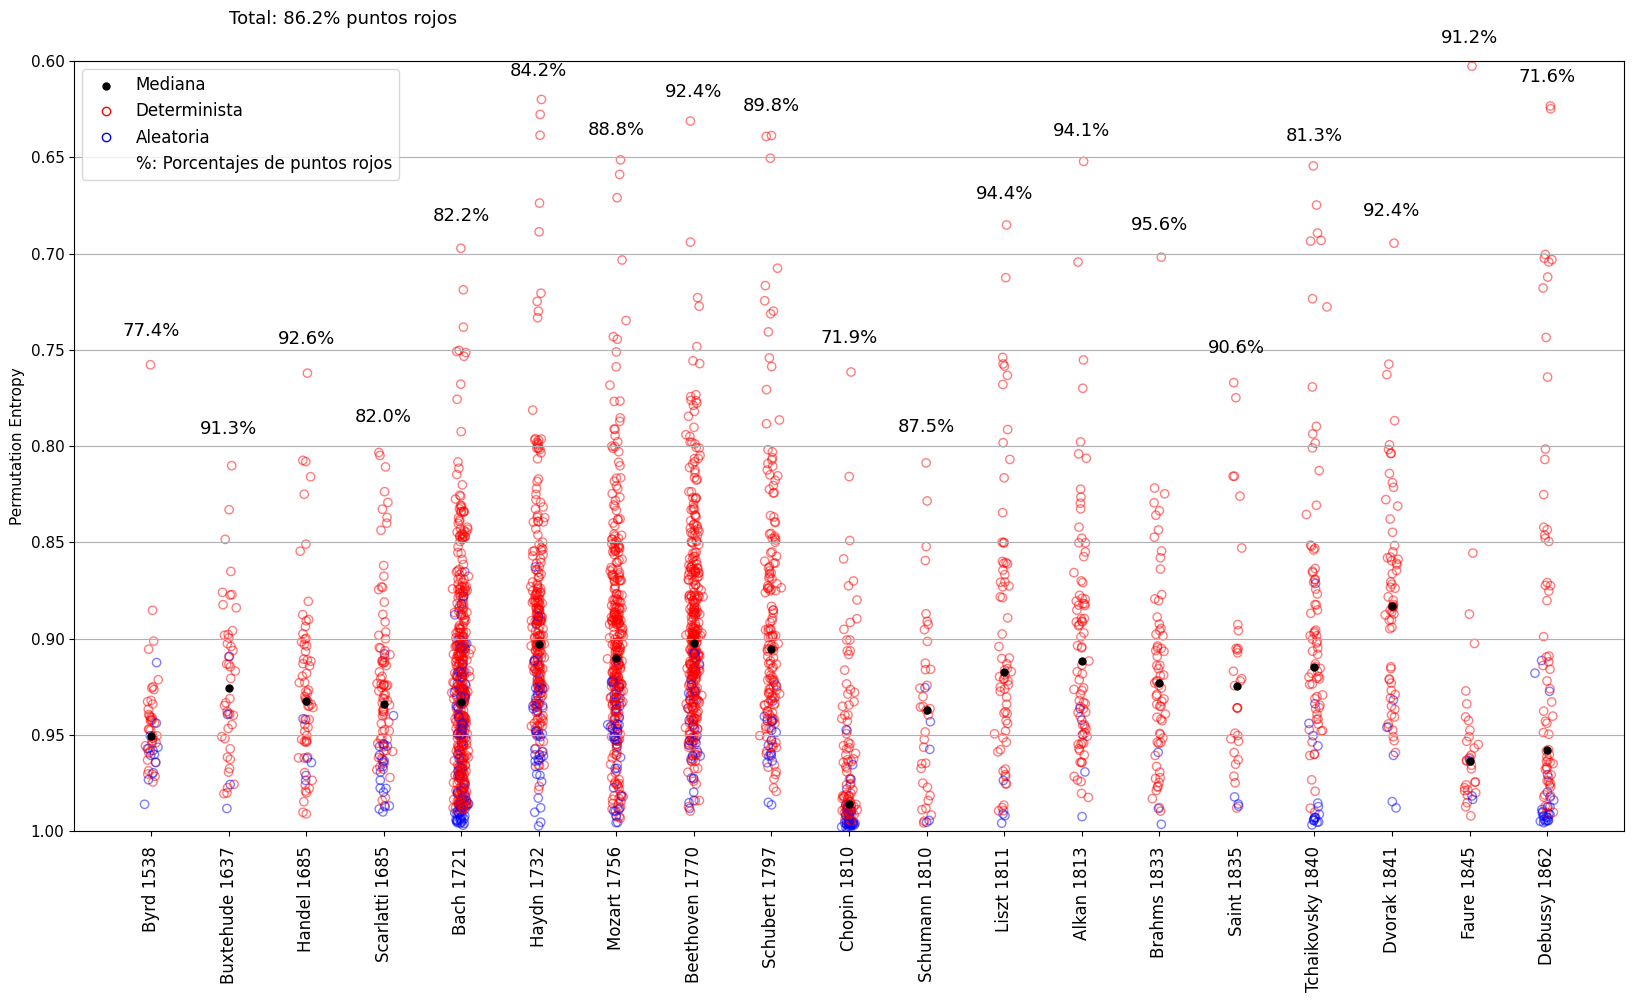

In [109]:
"""Scatter PEs"""

import numpy as np
import matplotlib.pyplot as plt
import os
from matplotlib.lines import Line2D

num_compositores = 19
PEs = []
PEs_null = []
carpeta = r'new_data\PEs_absdiff'
carpeta_null = r'new_data\PEs_null_absdiff'
for archivo,archivo_null in zip(os.listdir(carpeta), os.listdir(carpeta_null)):
    if "PEs" in archivo:
        ruta_completa = os.path.join(carpeta, archivo)
        ruta_completa_null = os.path.join(carpeta_null, archivo_null)
        array = np.load(ruta_completa)
        array_null = np.load(ruta_completa_null)
        PEs.append(array)
        PEs_null.append(array_null)  
# np.save("PEs_min.npy", np.array(PEs_null, dtype=object))
# Aquí, asume que `puntos` es la lista con los num_compositores elementos
puntos2 = [np.mean(array) for array in PEs_null]
mediana = [np.median(array) for array in PEs]
print('mean',np.mean(puntos2))

fig, ax = plt.subplots(figsize=(20, 10))
# box2 = ax.boxplot(data2, patch_artist=True)

total_red_points = 0
total_points = 0
porcentajes_PE = []
for i, (d, u) in enumerate(zip(PEs, PEs_null)):
    mask = d > 0.6

    # Aplicar máscara a ambos arrays
    d = d[mask]
    u = u[mask]
    # Añadir dispersión para evitar superposición
    x = np.random.normal(i + 1, 0.04, size=len(d))
    colors = ['red' if d_val < u_val else 'blue' for d_val, u_val in zip(d, [x for x in u])]
    plt.scatter(x, d, alpha=0.5, color='none', edgecolors=colors)
    # Calcular porcentaje de puntos rojos
    num_red = sum(c == 'red' for c in colors)
    total_points += len(d)
    total_red_points += num_red
    percentage_red = (num_red / len(d)) * 100
    porcentajes_PE.append(percentage_red)
    # Calcular la posición del texto sin exceder el margen superior
    
    # Añadir texto con el porcentaje
    ax.text(i + 1,np.min(d)*0.98, f'{percentage_red:.1f}%', ha='center', fontsize=13, color='black')

# np.save('porcentajes_run_avg_50.npy', np.array(porcentajes))
total_percentage_red = (total_red_points / total_points) * 100

# Añadir texto con el porcentaje total
ymin = ax.get_ylim()[0]   # límite inferior actual del eje y
xmin = ax.get_xlim()[0]   # si quieres fijarlo también en el mínimo de x, por ejemplo

# Añadir texto en coordenadas de datos
ax.text(xmin + 0.1*(ax.get_xlim()[1]-ax.get_xlim()[0]),  # un poquito a la derecha del xmin
        ymin,                                            # justo en ymin
        f'Total: {total_percentage_red:.1f}% puntos rojos',
        ha='left', va='bottom', fontsize=13, color='black')

ax.set_ylabel('Permutation Entropy', fontsize=11)
ax.tick_params(axis='y', labelsize=11)
ax.set_xticks(np.arange(1, num_compositores+1))

# ax.scatter(np.arange(1, num_compositores+1), puntos2, color='#87CEEB', s=25, zorder=3, marker = 'o', label=r'Umbral $\overline{U\{ N_J \}}$')
ax.scatter(np.arange(1, num_compositores+1), mediana, color='black',s=25,zorder=3,marker='o',label='Mediana')
# ax.plot(np.arange(1, num_compositores+1), puntos2, color='blue', linestyle='-', linewidth=0.8)
# ax.plot(np.arange(1, 18), mediana, color='red', linestyle='-', linewidth=0.8)
ax.plot([],[], marker = 'o',color='none', markeredgecolor='red', label = 'Determinista')
ax.plot([],[], marker='o', color='none', markeredgecolor='blue', label= 'Aleatoria')
ax.plot([],[], marker='none', color='none', label = '%: Porcentajes de puntos rojos')

# Agregar la leyenda al gráfico
ax.legend(loc='upper left',fontsize=12)
plt.gca().invert_yaxis()
ax.set_ylim(1,0.6)
ax.set_xticklabels([f"{composer} {datos_composers[composer]['Birth_year']} " for i, composer in enumerate(datos_composers.keys())], rotation=90,fontsize=12)
plt.grid(axis='y')
plt.show()

(517,)
0.9349671378081092 0.88488167408228


(0.0, 30.0)

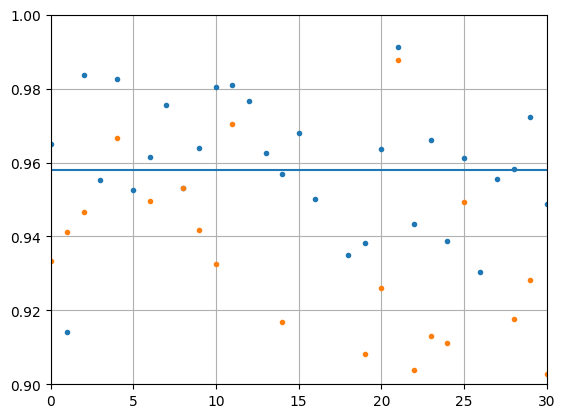

In [106]:
ar1 = np.load(r'new_data\PEs_null_absdiff\1721_Bach_PEs_null.npy')
ar2 = np.load(r'new_data\PEs_absdiff\1721_Bach_PEs.npy')
if 0.9388191125050739 in ar2:
    print("yes" )
print(np.shape(ar1))
print(ar1[18], ar2[18])
plt.plot(ar1, '.')
plt.plot(ar2, '.')
plt.axhline(y = np.mean(ar1))
plt.ylim(0.9,1)
plt.grid()
plt.xlim(0,30)

0.9666558275943803


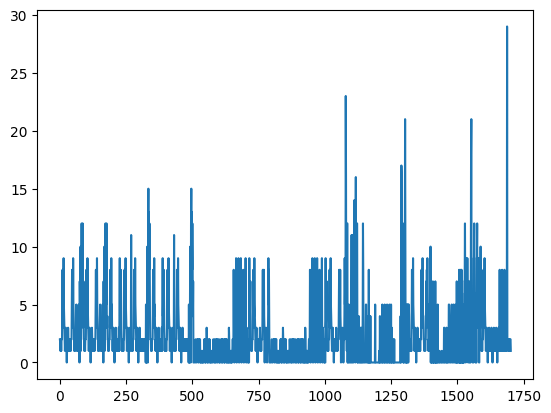

In [57]:
ar = composers['Alkan']['Serie_114']
from funciones import permutation_entropy

print(permutation_entropy(np.random.permutation(np.abs(np.diff(ar)))
))

plt.plot(np.abs(np.diff(ar)))

mean 0.9912566057426586


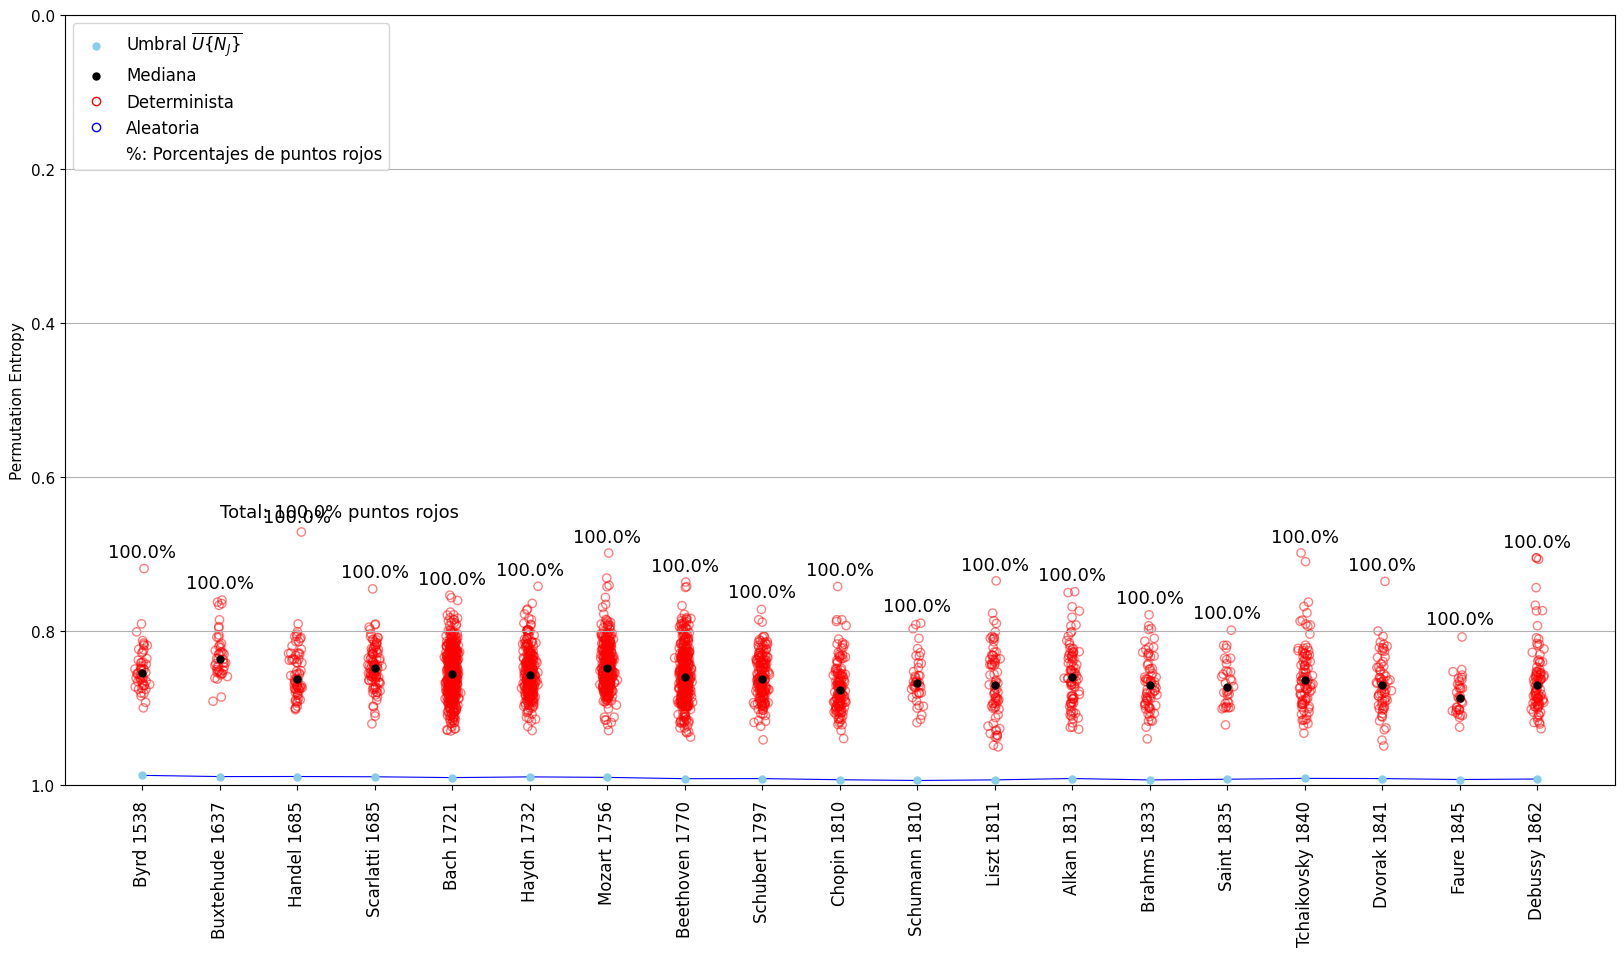

In [107]:
"""Scatter Shannon"""

import numpy as np
import matplotlib.pyplot as plt
import os
from matplotlib.lines import Line2D

num_compositores = 19
PEs = []
PEs_null = []
carpeta = r'new_data\shannon'
carpeta_null = r'new_data\PEs_null'
for archivo,archivo_null in zip(os.listdir(carpeta), os.listdir(carpeta_null)):
    if "shannon" in archivo:
        ruta_completa = os.path.join(carpeta, archivo)
        ruta_completa_null = os.path.join(carpeta_null, archivo_null)
        array = np.load(ruta_completa)
        array_null = np.load(ruta_completa_null)
        PEs.append(array)
        PEs_null.append(array_null)  
# np.save("PEs_min.npy", np.array(PEs_null, dtype=object))
# Aquí, asume que `puntos` es la lista con los num_compositores elementos
puntos2 = [np.mean(array) for array in PEs_null]
mediana = [np.median(array) for array in PEs]
print('mean',np.mean(puntos2))

fig, ax = plt.subplots(figsize=(20, 10))
# box2 = ax.boxplot(data2, patch_artist=True)

total_red_points = 0
total_points = 0
porcentajes_PE = []
for i, (d, u) in enumerate(zip(PEs, PEs_null)):
    # Añadir dispersión para evitar superposición
    x = np.random.normal(i + 1, 0.04, size=len(d))
    colors = ['red' if d_val < u_val else 'blue' for d_val, u_val in zip(d, [x for x in u])]
    plt.scatter(x, d, alpha=0.5, color='none', edgecolors=colors)
    # Calcular porcentaje de puntos rojos
    num_red = sum(c == 'red' for c in colors)
    total_points += len(d)
    total_red_points += num_red
    percentage_red = (num_red / len(d)) * 100
    porcentajes_PE.append(percentage_red)
    # Calcular la posición del texto sin exceder el margen superior
    
    # Añadir texto con el porcentaje
    ax.text(i + 1,np.min(d)*0.98, f'{percentage_red:.1f}%', ha='center', fontsize=13, color='black')

# np.save('porcentajes_run_avg_50.npy', np.array(porcentajes))
total_percentage_red = (total_red_points / total_points) * 100

# Añadir texto con el porcentaje total
ymin = ax.get_ylim()[0]   # límite inferior actual del eje y
xmin = ax.get_xlim()[0]   # si quieres fijarlo también en el mínimo de x, por ejemplo

# Añadir texto en coordenadas de datos
ax.text(xmin + 0.1*(ax.get_xlim()[1]-ax.get_xlim()[0]),  # un poquito a la derecha del xmin
        ymin,                                            # justo en ymin
        f'Total: {total_percentage_red:.1f}% puntos rojos',
        ha='left', va='bottom', fontsize=13, color='black')

ax.set_ylabel('Permutation Entropy', fontsize=11)
ax.tick_params(axis='y', labelsize=11)
ax.set_xticks(np.arange(1, num_compositores+1))

ax.scatter(np.arange(1, num_compositores+1), puntos2, color='#87CEEB', s=25, zorder=3, marker = 'o', label=r'Umbral $\overline{U\{ N_J \}}$')
ax.scatter(np.arange(1, num_compositores+1), mediana, color='black',s=25,zorder=3,marker='o',label='Mediana')
ax.plot(np.arange(1, num_compositores+1), puntos2, color='blue', linestyle='-', linewidth=0.8)
# ax.plot(np.arange(1, 18), mediana, color='red', linestyle='-', linewidth=0.8)
ax.plot([],[], marker = 'o',color='none', markeredgecolor='red', label = 'Determinista')
ax.plot([],[], marker='o', color='none', markeredgecolor='blue', label= 'Aleatoria')
ax.plot([],[], marker='none', color='none', label = '%: Porcentajes de puntos rojos')

# Agregar la leyenda al gráfico
ax.legend(loc='upper left',fontsize=12)
plt.gca().invert_yaxis()
ax.set_ylim(1,0)
ax.set_xticklabels([f"{composer} {datos_composers[composer]['Birth_year']} " for i, composer in enumerate(datos_composers.keys())], rotation=90,fontsize=12)
plt.grid(axis='y')
plt.show()

global (np.float64(0.06437980265605897), np.float64(0.010840451684582775))


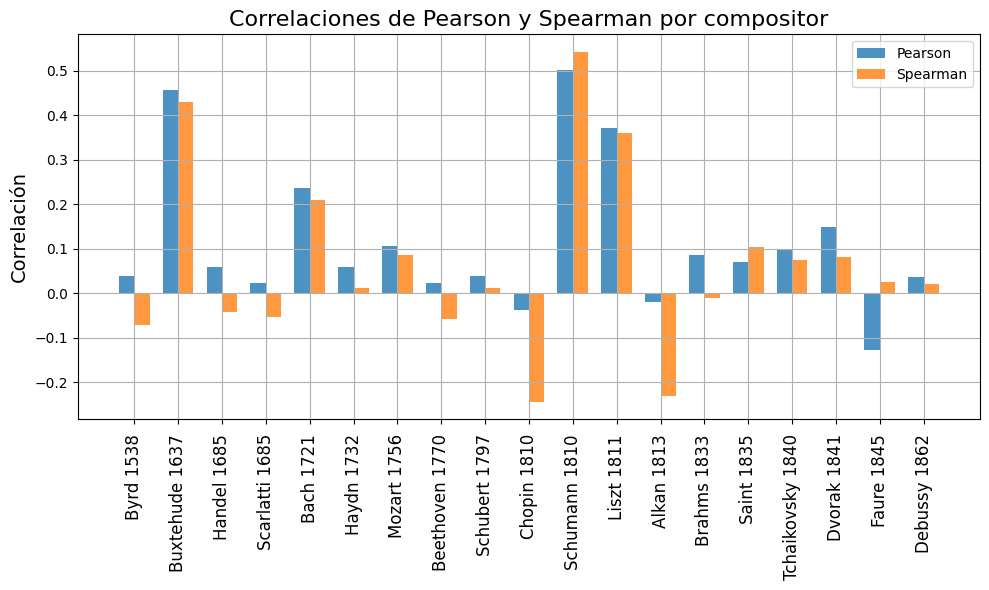

In [11]:
print("global",corr_puntos_rojos(np.concatenate(xi_index),np.concatenate(PEs),X_c = 1.0, Y_c=0.991))
pearson_corr = np.zeros(19)
spearman_corr = np.zeros(19)
for i, composer in enumerate(composers.keys()):
    pearson_corr[i], spearman_corr[i] = corr_puntos_rojos(xi_index[i],PEs[i],X_c = 1.0, Y_c=0.991)



# Configuración para gráfica de barras
x = np.arange(len(datos_composers))  # posiciones en el eje x
width = 0.35  # ancho de cada barra

fig, ax = plt.subplots(figsize=(10, 6))

# Barras para Pearson y Spearman
bars1 = ax.bar(x - width/2, pearson_corr, width, label='Pearson', alpha=0.8)
bars2 = ax.bar(x + width/2, spearman_corr, width, label='Spearman', alpha=0.8)

# Etiquetas y detalles
ax.set_ylabel('Correlación', fontsize=14)
ax.set_title('Correlaciones de Pearson y Spearman por compositor', fontsize=16)
ax.set_xticks(x)
ax.set_xticklabels(
    [f"{composer} {datos_composers[composer]['Birth_year']} " for composer in datos_composers.keys()],
    rotation=90,
    fontsize=12
)
ax.legend()

plt.tight_layout()
plt.grid()
# plt.ylim(-0.55,0.4)
plt.show()


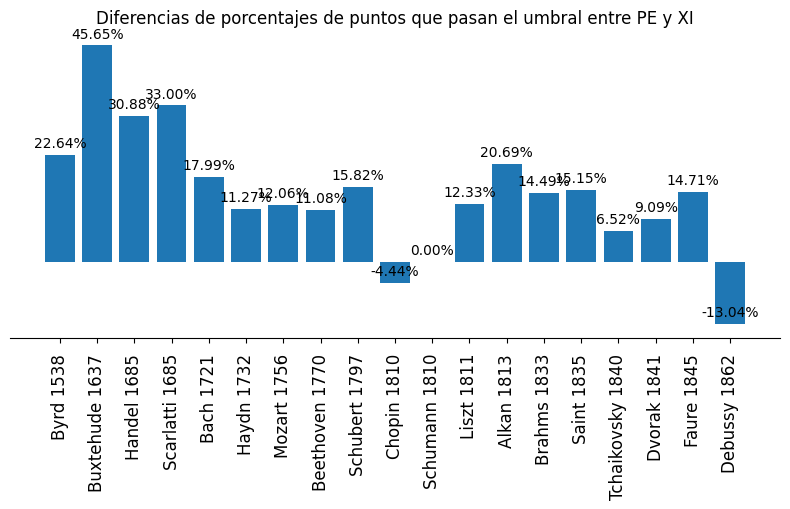

In [12]:
import matplotlib.pyplot as plt
import numpy as np


percentages = np.array(porcentajes_PE) - np.array(porcentajes_xi)

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(list(composers.keys()), percentages)

# Quitar eje Y
ax.yaxis.set_visible(False)
ax.spines['left'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)

# Colocar los valores arriba de cada barra
for bar, value in zip(bars, percentages):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 1,  # un poco arriba de la barra
            f"{value:.2f}%",
            ha='center', va='bottom', fontsize=10)

# Etiquetas del eje X como pediste
ax.set_xticks(np.arange(len(composers.keys())))
ax.set_xticklabels(
    [f"{composer} {datos_composers[composer]['Birth_year']} " 
     for composer in composers.keys()],
    rotation=90, fontsize=12
)

plt.tight_layout()
plt.title('Diferencias de porcentajes de puntos que pasan el umbral entre PE y XI')
plt.show()


PearsonRResult(statistic=np.float64(0.5061799153862635), pvalue=np.float64(0.02701269735563608))


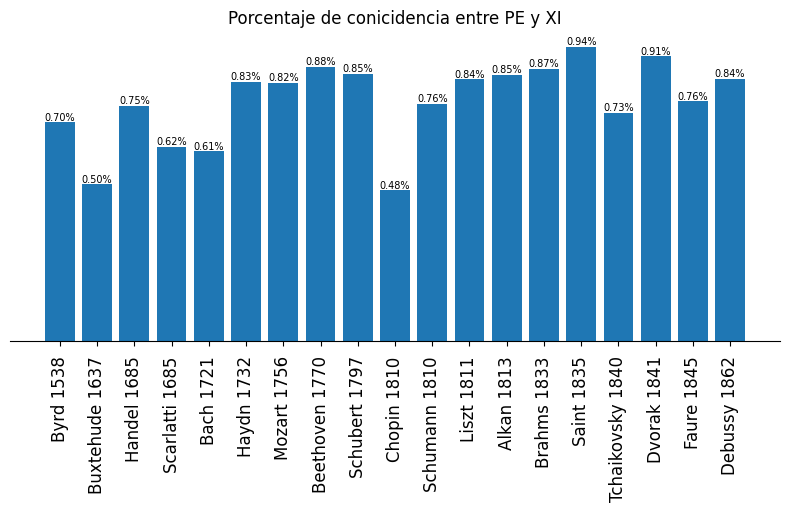

In [13]:
import matplotlib.pyplot as plt
import numpy as np


agreement_p = np.load(r'new_data\agreement_percent.npy')

print(pearsonr(agreement_p, porcentajes_PE))

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(list(composers.keys()), agreement_p)

# Quitar eje Y
ax.yaxis.set_visible(False)
ax.spines['left'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)

# Colocar los valores arriba de cada barra
for bar, value in zip(bars, agreement_p):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() ,  # un poco arriba de la barra
            f"{value:.2f}%",
            ha='center', va='bottom', fontsize=7)

# Etiquetas del eje X como pediste
ax.set_xticks(np.arange(len(composers.keys())))
ax.set_xticklabels(
    [f"{composer} {datos_composers[composer]['Birth_year']} " 
     for composer in composers.keys()],
    rotation=90, fontsize=12
)

plt.tight_layout()
plt.title('Porcentaje de conicidencia entre PE y XI')
plt.show()


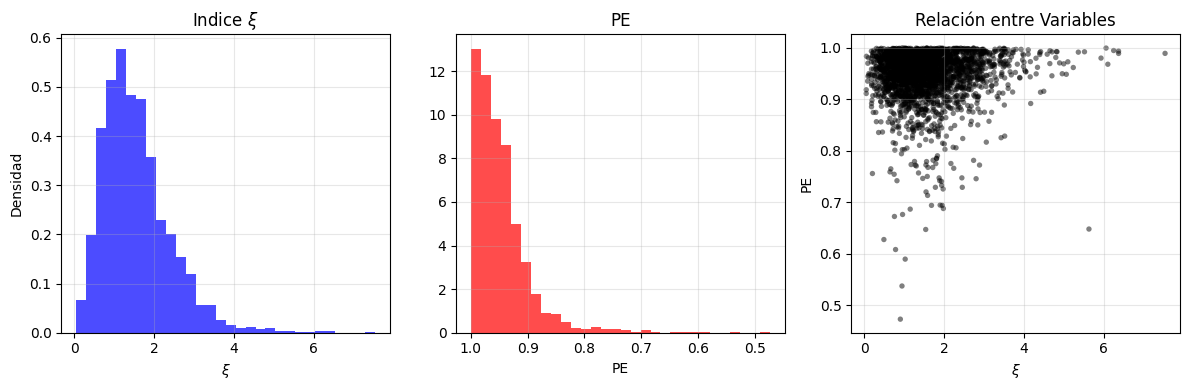

In [14]:
import os
import numpy as np
import matplotlib.pyplot as plt

folder_path1 = 'new_data/xi_index1'
folder_path2 = 'new_data/PEs'
arrays1 = []
arrays2 = []
for filename in os.listdir(folder_path1):
    if filename.endswith('.npy'):
        # print(filename)
        array = np.load(os.path.join(folder_path1, filename))[:,1] -0.2
        arrays1.extend(array)
for filename in os.listdir(folder_path2):
    if filename.endswith('.npy'):
        # print(filename)
        array = np.load(os.path.join(folder_path2, filename))
        arrays2.extend(array)


fig, axes = plt.subplots(1, 3, figsize=(12, 4))

# Histograma de la primera variable
axes[0].hist(arrays1, bins=30, alpha=0.7, color='blue', density=True)
axes[0].set_title(r"Indice $\xi$")
axes[0].set_xlabel(r"$\xi$")
axes[0].set_ylabel("Densidad")
axes[0].grid(alpha=0.3)

# Histograma de la segunda variable
axes[1].hist(arrays2, bins=30, alpha=0.7, color='red', density=True)
axes[1].set_title("PE")
axes[1].set_xlabel("PE")
axes[1].grid(alpha=0.3)
axes[1].invert_xaxis()

# Scatter entre ambas variables (subplot central)
axes[2].scatter(arrays1, arrays2, alpha=0.5, s=15, c="black", edgecolors="none")
axes[2].set_title("Relación entre Variables")
axes[2].set_xlabel(r"$\xi$")
axes[2].set_ylabel("PE")
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [15]:
af = [2,4,6]
af.extend(np.array([8,10]))
af

[2, 4, 6, np.int64(8), np.int64(10)]

2677 2677


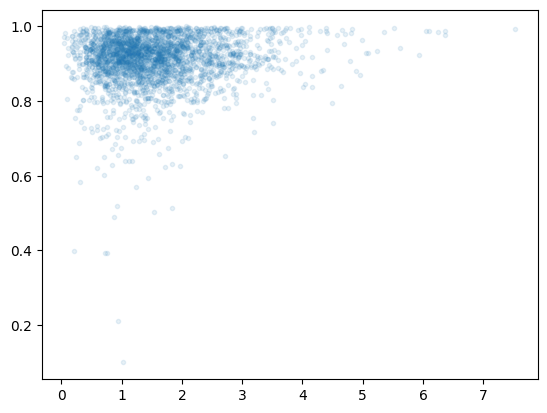

In [16]:
plt.plot(np.concatenate(xi_index), np.concatenate(PEs), '.', alpha=0.1)
print(len(np.concatenate(xi_index)), len(np.concatenate(PEs)  ))

In [1]:
from numba import njit
import numpy as np


@njit
def lehmer_code(perm):
    """Codifica una permutación en un índice único usando Lehmer code"""
    m = len(perm)
    code = 0
    factor = 1
    for i in range(m-1, -1, -1):
        c = 0
        for j in range(i+1, m):
            if perm[j] < perm[i]:
                c += 1
        code += c * factor
        factor *= (m - i)
    return code

@njit
def stable_argsort_by_value_then_index(x):
    m = x.shape[0]
    idx = np.arange(m)
    # insertion sort por clave (valor, índice)
    for i in range(1, m):
        key = idx[i]
        j = i - 1
        while j >= 0:
            a = x[idx[j]]
            b = x[key]
            if (a > b) or (a == b and idx[j] > key):  # (valor) y luego (índice)
                idx[j+1] = idx[j]
                j -= 1
            else:
                break
        idx[j+1] = key
    return idx

@njit
def permutation_entropy(arr, m=3, tau=1):
    n = len(arr)
    if n < m:
        return np.nan
    # m!:
    fact = 1
    for k in range(2, m+1):
        fact *= k
    counts = np.zeros(fact, dtype=np.int64)
    denom = n - (m-1)*tau
    for i in range(denom):
        subseq = np.empty(m, np.float64)
        for j in range(m):
            subseq[j] = arr[i + j*tau]
        idx = stable_argsort_by_value_then_index(subseq)
        code = lehmer_code(idx)      # tu misma función
        counts[code] += 1
    # entropía normalizada (independiente de base)
    probs = counts[counts > 0] / denom
    n_prohibidos = fact - len(probs)
    H = -np.sum(probs * np.log(probs))
    Hnorm = H / np.log(fact)
    return Hnorm

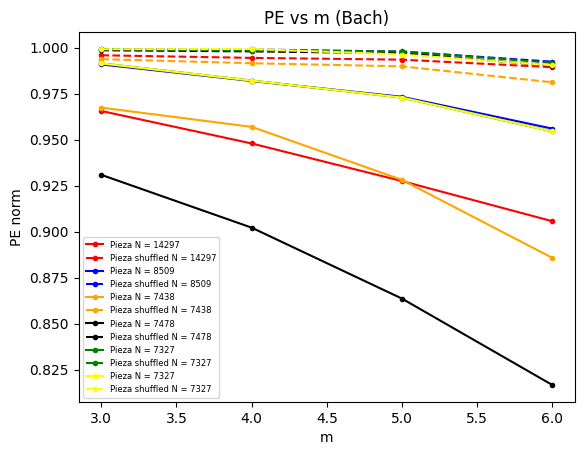

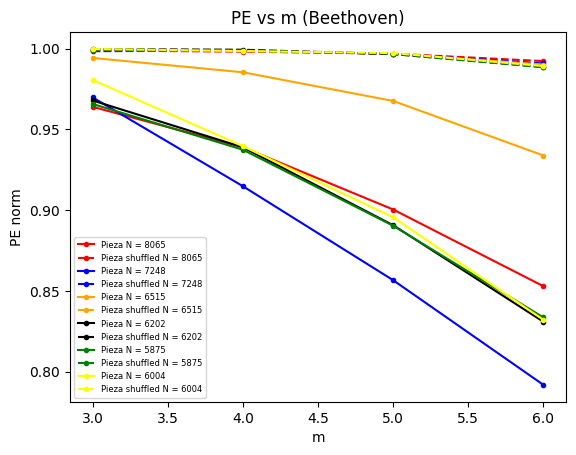

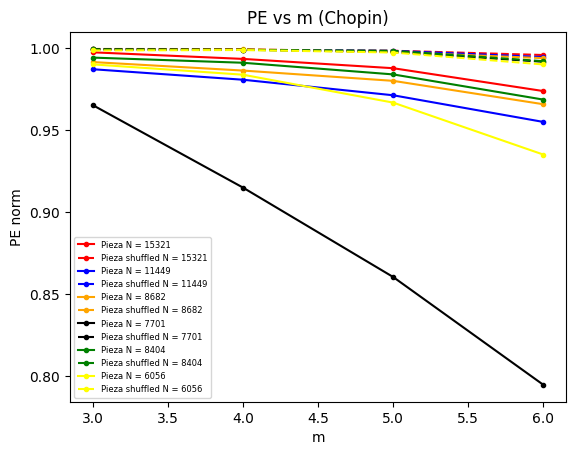

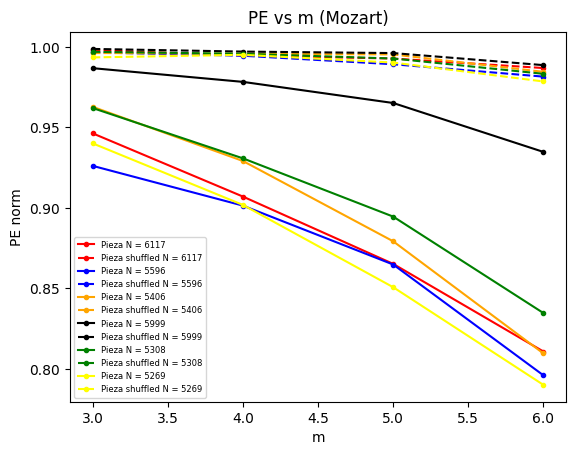

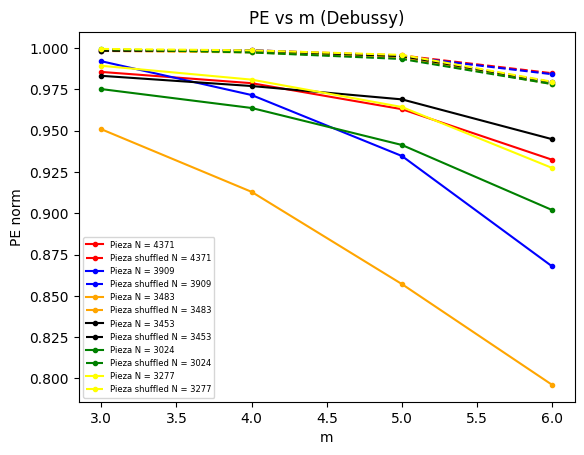

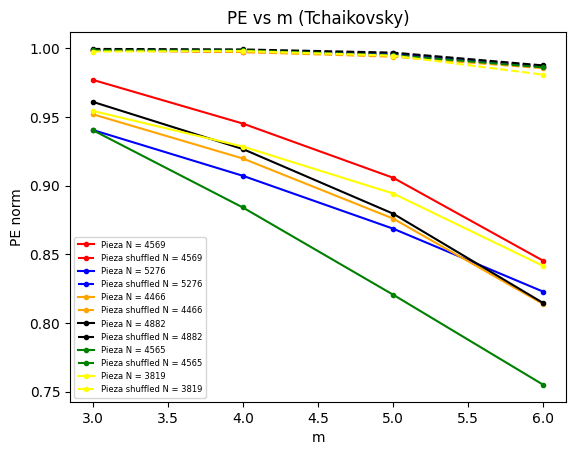

In [6]:
import matplotlib.pyplot as plt

compositores = ['Bach','Beethoven', 'Chopin', 'Mozart','Debussy','Tchaikovsky']
colors = ['red','blue','orange','black','green','yellow']
series_Bach = ['Serie_896','Serie_1805','Serie_2047','Serie_954','Serie_1806','Serie_1807']
series_Beethoven = ['Serie_560','Serie_592','Serie_249','Serie_205','Serie_204','Serie_214']
series_Chopin = ['Serie_183','Serie_192','Serie_1','Serie_44','Serie_15','Serie_17']
series_Mozart = ['Serie_36','Serie_42','Serie_27','Serie_2','Serie_35','Serie_34']
series_Debussy = ['Serie_118','Serie_10','Serie_181','Serie_97','Serie_122','Serie_124']
series_Tchaikovsky = ['Serie_246','Serie_249','Serie_245','Serie_28','Serie_250','Serie_247']

series_grandes = [series_Bach, series_Beethoven, series_Chopin, series_Mozart, series_Debussy, series_Tchaikovsky]
m = [3,4,5,6]
for i,subjects in enumerate(series_grandes):
    PEs = [[] for _ in range(6)] # 6 piezas
    PEs_null = [[] for _ in range(6)] # 6 piezas
    composer = compositores[i]
    for k,pieza in enumerate(subjects):
        arr = composers[composer][pieza]
        for j in range(len(m)): 
            arr = remove_consecutive_duplicates(arr,0.0)
            perm = np.random.permutation(arr)
            PE = permutation_entropy(np.array(arr),m=m[j],tau = 1)
            PE_null = permutation_entropy(perm,m=m[j],tau = 1)
            PEs[k].append(PE)
            PEs_null[k].append(PE_null)
        plt.plot(m,PEs[k],'-', marker = '.', label = f'Pieza N = {len(arr)}', color = colors[k])
        plt.plot(m,PEs_null[k],'--', marker = '.', label = f'Pieza shuffled N = {len(arr)}', color = colors[k])
    plt.xlabel('m')
    plt.legend(fontsize = 6)
    plt.title(f'PE vs m ({composer})')
    plt.ylabel('PE norm')
    plt.show()
    
    

In [30]:
np.shape(np.load(r'data\xi_index1\1637_Buxtehude_xi.npy'))

(46, 2)

⚠ No hay claves comunes tras normalizar. Revisa nombres o carpetas.
Ejemplos DATA: ['1538_Byrd_shannon', '1637_Buxtehude_shannon', '1685_Handel_shannon', '1685_Scarlatti_shannon', '1721_Bach_shannon']
Ejemplos NULL: ['1538_Byrd_PEs', '1637_Buxtehude_PEs', '1685_Handel_PEs', '1685_Scarlatti_PEs', '1721_Bach_PEs']


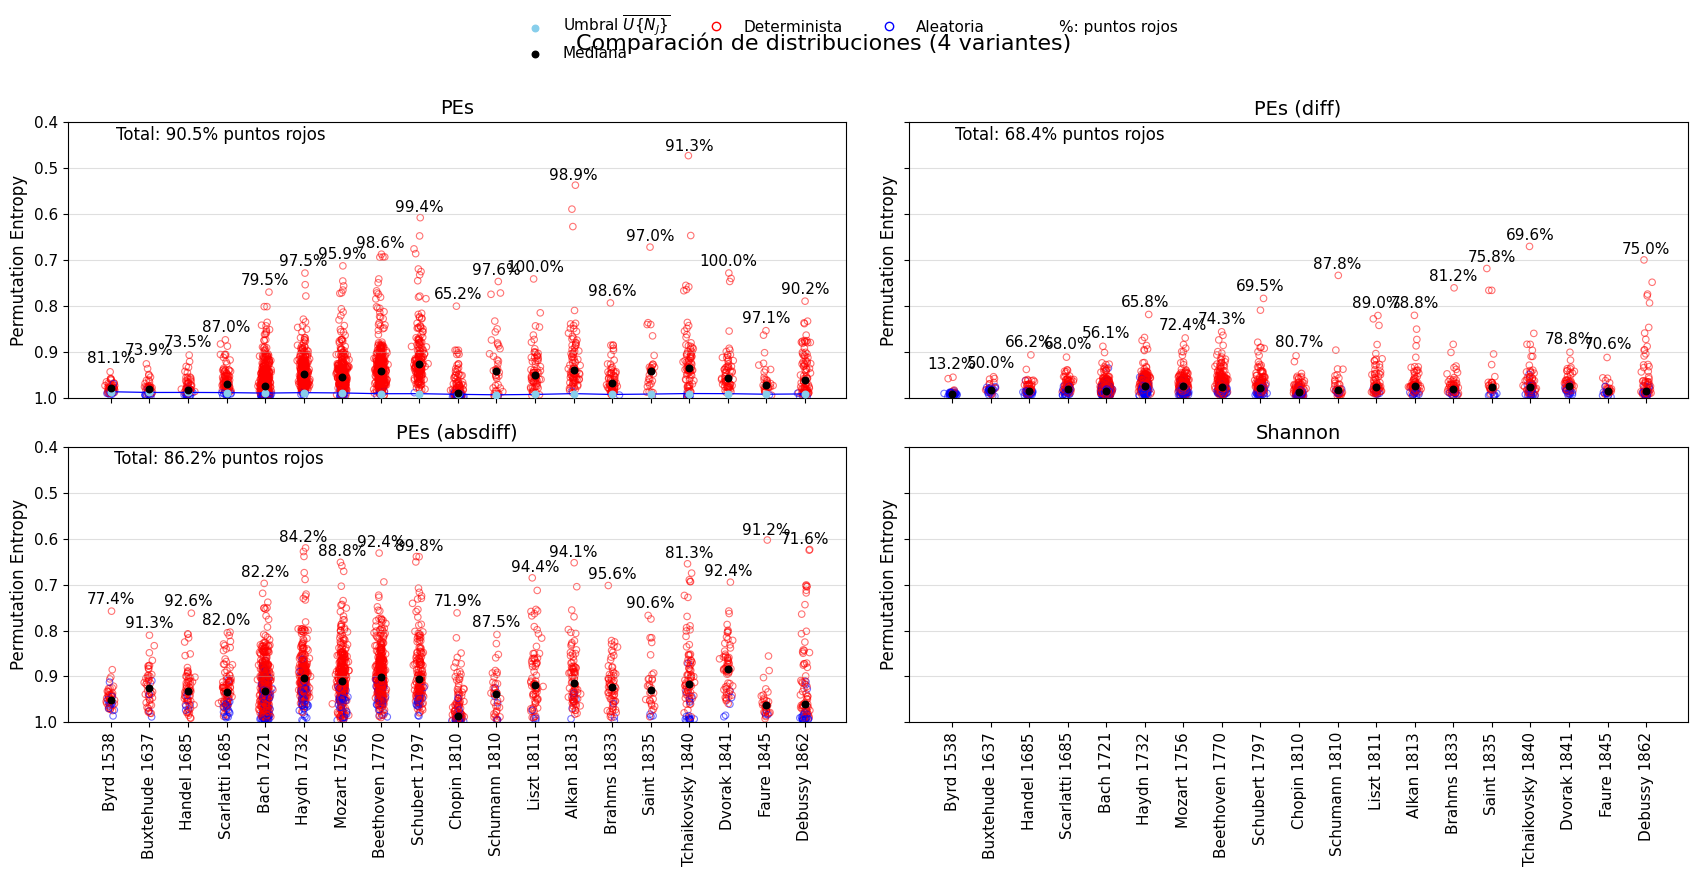

In [11]:
# -*- coding: utf-8 -*-
import os
import re
import numpy as np
import matplotlib.pyplot as plt

# =======================
# PARÁMETROS DE ESTILO
# =======================
DOT_SIZE = 22          # tamaño de los puntos
EDGE_ALPHA = 0.55      # transparencia del borde de los puntos
JITTER_STD = 0.06      # dispersión horizontal para evitar solapamiento
LINE_WIDTH = 0.9       # grosor de líneas guía
FONT_GENERAL = 12      # tamaño base de fuente (labels)
FONT_TICKS = 11        # tamaño de ticks
LEGEND_FONTSIZE = 11   # fuente de la leyenda
TITLE_SIZE = 14        # fuente del título de cada panel
PERCENT_FONTSIZE = 11  # fuente del % por compositor
SUPTITLE_SIZE = 16     # fuente del título general

BOTTOM_MARGIN = 0.28   # margen inferior para etiquetas rotadas
LEFT_MARGIN = 0.08
RIGHT_MARGIN = 0.98
TOP_MARGIN = 0.88

# =======================
# NOMBRADO / CARGA
# =======================
def normalize_key(fname):
    """
    Convierte:
      '1538_Byrd_PEs.npy'         -> '1538_Byrd_PEs'
      '1538_Byrd_PEs_null.npy'    -> '1538_Byrd_PEs'
    Solo remueve un sufijo '_null' si existe.
    """
    stem = os.path.splitext(os.path.basename(fname))[0]
    stem = re.sub(r'_null$', '', stem, flags=re.IGNORECASE)
    return stem

def load_matched_arrays(folder_data, folder_null):
    """
    Empareja data y null por clave normalizada (quitando solo '_null').
    Retorna: data_arrays, null_arrays, used_names (claves usadas en orden).
    """
    data_files = [f for f in os.listdir(folder_data) if f.lower().endswith('.npy')]
    null_files = [f for f in os.listdir(folder_null) if f.lower().endswith('.npy')]

    by_key_data = {}
    for f in data_files:
        k = normalize_key(f)
        by_key_data.setdefault(k, []).append(os.path.join(folder_data, f))

    by_key_null = {}
    for f in null_files:
        k = normalize_key(f)
        by_key_null.setdefault(k, []).append(os.path.join(folder_null, f))

    common = sorted(set(by_key_data.keys()) & set(by_key_null.keys()))
    if not common:
        print("⚠ No hay claves comunes tras normalizar. Revisa nombres o carpetas.")
        print("Ejemplos DATA:", [normalize_key(f) for f in data_files[:5]])
        print("Ejemplos NULL:", [normalize_key(f) for f in null_files[:5]])

    data_arrays, null_arrays, used_names = [], [], []
    for k in common:
        data_arrays.append(np.load(by_key_data[k][0], allow_pickle=True))
        null_arrays.append(np.load(by_key_null[k][0], allow_pickle=True))
        used_names.append(k)
    return data_arrays, null_arrays, used_names

# =======================
# ETIQUETAS DE EJE X
# =======================
def derive_labels_from_used_names(used_names):
    """
    Deriva etiquetas 'Composer' desde keys tipo '1538_Byrd_PEs'.
    Si no puede, usa el propio key.
    """
    labels = []
    for key in used_names:
        tok = key.split('_')
        if len(tok) >= 2:
            labels.append(tok[1])
        else:
            labels.append(key)
    return labels

def per_composer_labels(used_names, num_compositores):
    """
    Intenta usar datos_composers (si existe en el entorno):
      etiqueta: 'Composer BirthYear'
    Si no existe, deriva de los nombres de archivo.
    """
    try:
        # datos_composers debe ser un dict global: { "Composer": {"Birth_year": 1685}, ... }
        dc = globals().get('datos_composers', None)
    except Exception:
        dc = None

    labels = []
    if isinstance(dc, dict) and len(dc) > 0:
        # intenta mapear por compositor derivado del nombre
        derived = derive_labels_from_used_names(used_names)[:num_compositores]
        for comp in derived:
            if comp in dc and 'Birth_year' in dc[comp]:
                labels.append(f"{comp} {dc[comp]['Birth_year']}")
            else:
                labels.append(comp)
    else:
        labels = derive_labels_from_used_names(used_names)[:num_compositores]
    return labels

# =======================
# PANEL
# =======================
def plot_panel(ax, folder_data, folder_null, title, num_compositores=19,
               mask_min=None, show_threshold=True):
    """
    Dibuja un panel con scatter por compositor:
      - puntos rojos si d < u (determinista), azules lo contrario.
      - mediana (negro) y umbral (promedio null, azul) opcional.
      - % por compositor y % total del panel.
    """
    PEs, PEs_null, used_names = load_matched_arrays(folder_data, folder_null)

    # if len(PEs) == 0:
    #     ax.text(0.5, 0.5, "No hay pares .npy coincidentes", ha='center', va='center',
    #             transform=ax.transAxes, fontsize=FONT_GENERAL)
    #     ax.set_title(title, fontsize=TITLE_SIZE)
    #     ax.grid(axis='y', alpha=0.4)
    #     return [], []

    n_comp = min(num_compositores, len(PEs))
    puntos_null_mean = []
    medianas_data = []

    total_red_points = 0
    total_points = 0

    for i in range(n_comp):
        d = np.asarray(PEs[i]).ravel()
        u = np.asarray(PEs_null[i]).ravel()

        if mask_min is not None:
            mask = d > mask_min
            d = d[mask]
            u = u[mask]

        if d.size == 0 or u.size == 0:
            puntos_null_mean.append(np.nan)
            medianas_data.append(np.nan)
            continue

        puntos_null_mean.append(np.mean(u))
        medianas_data.append(np.median(d))

        x = np.random.normal(i + 1, JITTER_STD, size=d.size)
        colors = ['red' if d_val < u_val else 'blue' for d_val, u_val in zip(d, u)]

        ax.scatter(x, d, s=DOT_SIZE, alpha=EDGE_ALPHA, facecolors='none',
                   edgecolors=colors, linewidths=0.8)

        num_red = sum(c == 'red' for c in colors)
        total_points += d.size
        total_red_points += num_red
        percentage_red = 100.0 * num_red / d.size

        y_text = (np.nanmin(d) * 0.98) if np.isfinite(np.nanmin(d)) else 0.02
        ax.text(i + 1, y_text, f'{percentage_red:.1f}%', ha='center',
                fontsize=PERCENT_FONTSIZE, color='black')

    idxs = np.arange(1, n_comp + 1)
    puntos_null_mean = np.array(puntos_null_mean, dtype=float)
    medianas_data = np.array(medianas_data, dtype=float)

    if show_threshold and np.isfinite(puntos_null_mean).any():
        ax.scatter(idxs, puntos_null_mean, color='#87CEEB', s=DOT_SIZE, zorder=3,
                   marker='o', label=r'Umbral $\overline{U\{N_J\}}$')
        ax.plot(idxs, puntos_null_mean, color='blue', linestyle='-', linewidth=LINE_WIDTH)

    if np.isfinite(medianas_data).any():
        ax.scatter(idxs, medianas_data, color='black', s=DOT_SIZE, zorder=3,
                   marker='o', label='Mediana')

    # Leyendas "vacías" para la codificación de color
    ax.plot([], [], marker='o', color='none', markeredgecolor='red',
            label='Determinista')
    ax.plot([], [], marker='o', color='none', markeredgecolor='blue',
            label='Aleatoria')
    ax.plot([], [], marker='none', color='none', label='%: puntos rojos')

    # % total del panel
    if total_points > 0:
        total_percentage_red = 100.0 * total_red_points / total_points
        x0, x1 = ax.get_xlim()
        y0, y1 = ax.get_ylim()
        y_min_data = min(y0, y1)  # por si aún no invertimos el eje
        ax.text(x0 + 0.06 * (x1 - x0), y_min_data,
                f'Total: {total_percentage_red:.1f}% puntos rojos',
                ha='left', va='bottom', fontsize=FONT_GENERAL, color='black')

    ax.set_title(title, fontsize=TITLE_SIZE)
    ax.grid(axis='y', alpha=0.4)
    ax.set_xticks(np.arange(1, n_comp + 1))
    ax.tick_params(axis='both', labelsize=FONT_TICKS)

    return used_names, n_comp

# =======================
# FIGURA 2×2 (CONFIGURA RUTAS)
# =======================
# Panel A: PEs vs PEs_null
FOLDER_A_DATA = r'new_data\PEs'
FOLDER_A_NULL = r'new_data\PEs_null'
TITLE_A = 'PEs'

# Panel B: PEs_diff vs PEs_null_diff (con filtro d > 0.6)
FOLDER_B_DATA = r'new_data\PEs_diff'
FOLDER_B_NULL = r'new_data\PEs_null_diff'
TITLE_B = 'PEs (diff)'

# Panel C: PEs_absdiff vs PEs_null_absdiff (si existen)
FOLDER_C_DATA = r'new_data\PEs_absdiff'
FOLDER_C_NULL = r'new_data\PEs_null_absdiff'
TITLE_C = 'PEs (absdiff)'

# Panel D: Shannon vs su null (si tu null es el general de PEs, úsalo)
FOLDER_D_DATA = r'new_data\shannon'
FOLDER_D_NULL = r'new_data\PEs_null'  # ajusta si tienes una carpeta null específica
TITLE_D = 'Shannon'

# =======================
# PLOTEO
# =======================
num_compositores = 19
fig, axs = plt.subplots(2, 2, figsize=(18, 10), sharex=True, sharey=True)

# Paneles
used_A, nA = plot_panel(axs[0, 0], FOLDER_A_DATA, FOLDER_A_NULL, TITLE_A,
                        num_compositores=num_compositores, mask_min=None, show_threshold=True)

used_B, nB = plot_panel(axs[0, 1], FOLDER_B_DATA, FOLDER_B_NULL, TITLE_B,
                        num_compositores=num_compositores, mask_min=0.6, show_threshold=False)

used_C, nC = plot_panel(axs[1, 0], FOLDER_C_DATA, FOLDER_C_NULL, TITLE_C,
                        num_compositores=num_compositores, mask_min=0.6, show_threshold=False)

used_D, nD = plot_panel(axs[1, 1], FOLDER_D_DATA, FOLDER_D_NULL, TITLE_D,
                        num_compositores=num_compositores, mask_min=None, show_threshold=True)

# Ejes y estilo global
for ax in axs.ravel():
    ax.invert_yaxis()          # mismo convenio: 1 arriba, 0 abajo
    ax.set_ylim(1.0, 0.4)      # mismo rango para comparar
    ax.set_ylabel('Permutation Entropy', fontsize=FONT_GENERAL)

# Etiquetas X (intenta usar datos_composers si existe; si no, derive de archivos)
# Toma el panel A como referencia para los nombres usados; si no hay, usa el primero que tenga datos.
pick_used = used_A or used_B or used_C or used_D
pick_n = nA or nB or nC or nD
if pick_used and pick_n:
    labels = per_composer_labels(pick_used, pick_n)
    xticks = np.arange(1, len(labels) + 1)
    for ax in axs[1, :]:  # solo fila inferior
        ax.set_xticks(xticks)
        ax.set_xticklabels(labels, rotation=90, fontsize=FONT_TICKS)
else:
    # fallback genérico
    xticks = np.arange(1, num_compositores + 1)
    for ax in axs[1, :]:
        ax.set_xticks(xticks)
        ax.set_xticklabels([str(i) for i in xticks], rotation=90, fontsize=FONT_TICKS)

# Leyenda única
handles, lab = axs[0, 0].get_legend_handles_labels()
fig.legend(handles, lab, loc='upper center', ncol=4, fontsize=LEGEND_FONTSIZE, frameon=False)

fig.suptitle('Comparación de distribuciones (4 variantes)', fontsize=SUPTITLE_SIZE, y=0.97)

# Márgenes y espaciado
plt.subplots_adjust(left=LEFT_MARGIN, right=RIGHT_MARGIN,
                    bottom=BOTTOM_MARGIN, top=TOP_MARGIN, wspace=0.08, hspace=0.18)
plt.margins(x=0.02)
plt.show()
